# RQ1: Missing Data Robustness

Kaggle-ready notebook. It auto-detects `AirQualityUCI.csv` and `energydata_complete.csv` / `KAG_energydata_complete.csv`, then saves result tables as CSV and figures as PDF in `/kaggle/working/`.


Air Quality path: /kaggle/input/datasets/primnatoms/airqualityuci/AirQualityUCI.csv
Energy path: /kaggle/input/datasets/primnatoms/energydata-complete/KAG_energydata_complete.csv

Dataset: Air Quality, Target: CO(GT), Shape: (5993, 96)
Training: Air Quality Random Forest
Training: Air Quality HistGradientBoosting
Training: Air Quality MLP

Dataset: Appliances Energy, Target: Appliances, Shape: (5993, 224)
Training: Appliances Energy Random Forest
Training: Appliances Energy HistGradientBoosting
Training: Appliances Energy MLP


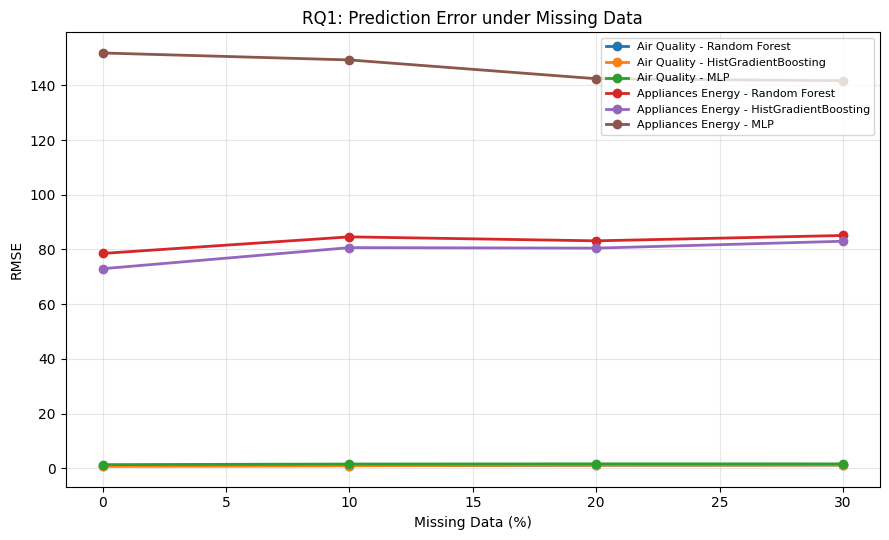

,Dataset,Target,Missing Data (%),Random Forest RMSE,Random Forest MAE,Random Forest R2,HistGradientBoosting RMSE,HistGradientBoosting MAE,HistGradientBoosting R2,MLP RMSE,MLP MAE,MLP R2
0,Air Quality,CO(GT),0,0.802082,0.530581,0.730463,0.836417,0.552304,0.706893,1.323852,1.025287,0.265724
1,Air Quality,CO(GT),10,0.938121,0.610189,0.631279,0.955487,0.622814,0.617501,1.544382,1.161160,0.000713
2,Air Quality,CO(GT),20,1.106805,0.711334,0.486757,1.128126,0.732901,0.466793,1.617313,1.180182,-0.095895
3,Air Quality,CO(GT),30,1.175894,0.777088,0.420682,1.192406,0.793294,0.404298,1.600844,1.190852,-0.073689
4,Appliances Energy,Appliances,0,78.538674,47.893288,0.316511,72.953401,42.482564,0.410267,151.822801,123.939801,-1.554104
5,Appliances Energy,Appliances,10,84.599886,48.087258,0.206944,80.665328,44.520818,0.278995,149.283832,119.228626,-1.469392
6,Appliances Energy,Appliances,20,83.149739,47.173913,0.233898,80.483008,44.764479,0.282250,142.416894,112.616287,-1.247437
7,Appliances Energy,Appliances,30,85.103071,45.600895,0.197482,82.996631,44.648125,0.236717,141.685410,110.766469,-1.224410


Saved table: /kaggle/working/rq1_missing_data_outputs/Table1_RQ1_missing_data_performance.csv
Saved figure: /kaggle/working/rq1_missing_data_outputs/Figure1_RQ1_missing_data_performance.pdf


In [1]:

# ============================================================
# Common setup for robust AI experiments on Kaggle
# Datasets:
# 1) AirQualityUCI.csv
# 2) energydata_complete.csv / KAG_energydata_complete.csv
# ============================================================

import os, glob, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, ks_2samp

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def find_file(possible_names):
    if isinstance(possible_names, str):
        possible_names = [possible_names]
    for filename in possible_names:
        matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
        if matches:
            return matches[0]
    for filename in possible_names:
        local = f"/mnt/data/{filename}"
        if os.path.exists(local):
            return local
    print("Available files:")
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            print(os.path.join(root, f))
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

AIR_PATH = find_file(["AirQualityUCI.csv", "AirQualityUCI(2).csv"])
ENERGY_PATH = find_file(["energydata_complete.csv", "KAG_energydata_complete.csv"])

print("Air Quality path:", AIR_PATH)
print("Energy path:", ENERGY_PATH)

def ensure_output_dir(name):
    out = f"/kaggle/working/{name}"
    if not os.path.exists("/kaggle/working"):
        out = f"./{name}"
    os.makedirs(out, exist_ok=True)
    return out

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def load_air_quality(path=AIR_PATH):
    df = pd.read_csv(path, sep=None, engine="python")
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
    if "Date" in df.columns and "Time" in df.columns:
        df["datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce", dayfirst=True)
        df = df.sort_values("datetime").drop(columns=["Date", "Time"])
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df = df.replace(-200, np.nan)
    numeric = df.select_dtypes(include=[np.number]).copy()
    numeric = numeric.dropna(axis=1, thresh=max(1, int(0.6 * len(numeric))))
    numeric = numeric.interpolate(limit_direction="both").ffill().bfill()
    return numeric

def load_energy(path=ENERGY_PATH):
    df = pd.read_csv(path)
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.sort_values("date").drop(columns=["date"])
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    numeric = df.select_dtypes(include=[np.number]).copy()
    numeric = numeric.replace([np.inf, -np.inf], np.nan)
    numeric = numeric.interpolate(limit_direction="both").ffill().bfill()
    return numeric

def make_supervised(df, target=None, lag=3, max_rows=6000):
    df = df.copy()
    if len(df) > max_rows:
        df = df.iloc[:max_rows].copy()
    if target is None:
        target = df.columns[0]
    for l in range(1, lag + 1):
        for c in df.columns:
            df[f"{c}_lag{l}"] = df[c].shift(l)
    df["target_next"] = df[target].shift(-1)
    df = df.dropna()
    X = df.drop(columns=["target_next"])
    y = df["target_next"]
    return X, y, target

def prepare_datasets(max_rows=6000, lag=3):
    air = load_air_quality()
    energy = load_energy()
    air_target = next((c for c in ["CO(GT)", "NO2(GT)", "C6H6(GT)", "T"] if c in air.columns), air.columns[0])
    energy_target = "Appliances" if "Appliances" in energy.columns else energy.columns[0]
    X_air, y_air, t_air = make_supervised(air, target=air_target, lag=lag, max_rows=max_rows)
    X_energy, y_energy, t_energy = make_supervised(energy, target=energy_target, lag=lag, max_rows=max_rows)
    return {"Air Quality": (X_air, y_air, t_air), "Appliances Energy": (X_energy, y_energy, t_energy)}

def train_test_time_split(X, y, train_frac=0.7):
    split = int(len(X) * train_frac)
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

def build_models():
    return {
        "Random Forest": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=120, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]),
        "HistGradientBoosting": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE))]),
        "MLP": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_STATE))])
    }

def corrupt_missing(X, rate):
    Xc = X.copy()
    if rate <= 0:
        return Xc
    rng = np.random.default_rng(RANDOM_STATE + int(rate * 1000))
    mask = rng.random(Xc.shape) < rate
    return Xc.mask(mask)

def corrupt_noise(X, noise_level):
    Xc = X.copy()
    if noise_level <= 0:
        return Xc
    std = Xc.std(numeric_only=True).replace(0, 1).values
    rng = np.random.default_rng(RANDOM_STATE + int(noise_level * 1000))
    noise = rng.normal(0, noise_level, size=Xc.shape) * std
    return Xc + noise

def evaluate_regression(y_true, pred):
    return {"RMSE": rmse(y_true, pred), "MAE": float(mean_absolute_error(y_true, pred)), "R2": float(r2_score(y_true, pred))}

# ============================================================
# RQ1: Missing Data Robustness
# ============================================================
OUT = ensure_output_dir("rq1_missing_data_outputs")
datasets = prepare_datasets(max_rows=6000, lag=3)
missing_rates = [0.0, 0.10, 0.20, 0.30]
rows = []
for dataset_name, (X, y, target) in datasets.items():
    print(f"\nDataset: {dataset_name}, Target: {target}, Shape: {X.shape}")
    X_train, X_test, y_train, y_test = train_test_time_split(X, y)
    models = build_models()
    for model_name, model in models.items():
        print("Training:", dataset_name, model_name)
        model.fit(X_train, y_train)
    for rate in missing_rates:
        X_eval = corrupt_missing(X_test, rate)
        row = {"Dataset": dataset_name, "Target": target, "Missing Data (%)": int(rate * 100)}
        for model_name, model in models.items():
            pred = model.predict(X_eval)
            metrics = evaluate_regression(y_test, pred)
            row[f"{model_name} RMSE"] = metrics["RMSE"]
            row[f"{model_name} MAE"] = metrics["MAE"]
            row[f"{model_name} R2"] = metrics["R2"]
        rows.append(row)
table = pd.DataFrame(rows)
table_path = f"{OUT}/Table1_RQ1_missing_data_performance.csv"
table.to_csv(table_path, index=False)
plt.figure(figsize=(9, 5.5))
for dataset_name in table["Dataset"].unique():
    subset = table[table["Dataset"] == dataset_name]
    for model_name in ["Random Forest", "HistGradientBoosting", "MLP"]:
        plt.plot(subset["Missing Data (%)"], subset[f"{model_name} RMSE"], marker="o", linewidth=2, label=f"{dataset_name} - {model_name}")
plt.xlabel("Missing Data (%)")
plt.ylabel("RMSE")
plt.title("RQ1: Prediction Error under Missing Data")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
fig_path = f"{OUT}/Figure1_RQ1_missing_data_performance.pdf"
plt.savefig(fig_path)
plt.show()
display(table)
print("Saved table:", table_path)
print("Saved figure:", fig_path)
